0.68257
0.46590


c:\Users\qipe\qutip_simulation\.venv\Lib\site-packages\qutip\solver\options.py:16: FutureWarning: Dedicated options class are no longer needed, options should be passed as dict to solvers.
  warnings.warn(


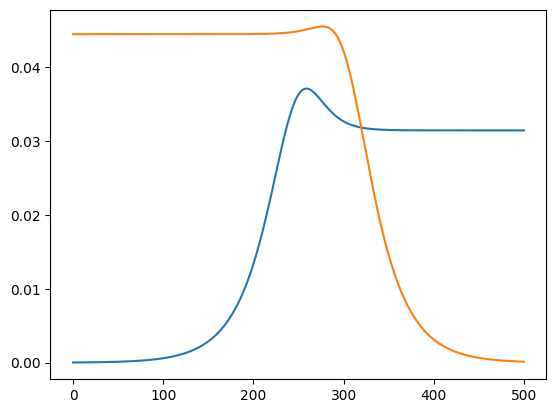

In [5]:
import qutip as qt
import matplotlib.pyplot as plt
import numpy as np

n_cutoff_A = 5
n_cutoff_B = 5
n_cutoff_rA = 4
n_cutoff_rB = 4


b_A = qt.tensor(qt.destroy(n_cutoff_A), qt.qeye(n_cutoff_rA), qt.qeye(n_cutoff_rB), qt.qeye(n_cutoff_B))
b_B = qt.tensor(qt.qeye(n_cutoff_A), qt.qeye(n_cutoff_rA), qt.qeye(n_cutoff_rB), qt.destroy(n_cutoff_B))
a_A = qt.tensor(qt.qeye(n_cutoff_A), qt.destroy(n_cutoff_rA), qt.qeye(n_cutoff_rB), qt.qeye(n_cutoff_B))
a_B = qt.tensor(qt.qeye(n_cutoff_A), qt.qeye(n_cutoff_rA), qt.destroy(n_cutoff_rB), qt.qeye(n_cutoff_B))

f0_A = qt.tensor(qt.basis(n_cutoff_A, 2), qt.basis(n_cutoff_rA, 0), qt.basis(n_cutoff_rB, 0), qt.basis(n_cutoff_B, 0))
g1_A = qt.tensor(qt.basis(n_cutoff_A, 0), qt.basis(n_cutoff_rA, 1), qt.basis(n_cutoff_rB, 0), qt.basis(n_cutoff_B, 0))
f0_B = qt.tensor(qt.basis(n_cutoff_A, 0), qt.basis(n_cutoff_rA, 0), qt.basis(n_cutoff_rB, 0), qt.basis(n_cutoff_B, 2))
g1_B = qt.tensor(qt.basis(n_cutoff_A, 0), qt.basis(n_cutoff_rA, 0), qt.basis(n_cutoff_rB, 1), qt.basis(n_cutoff_B, 0))
# e0_A = qt.tensor(qt.basis(n_cutoff_A, 1), qt.basis(n_cutoff_rA, 0), qt.basis(n_cutoff_rB, 0), qt.basis(n_cutoff_B, 0))

alpha_A = -0.3 * 2 * np.pi
chi_A = -0.006 * 2 * np.pi
alpha_B = -0.3 * 2 * np.pi
chi_B = -0.006 * 2 * np.pi
eta = 1.
kappa_A = 0.02 * 2 * np.pi
kappa_B = 0.03 * 2 * np.pi

args = {"centerA":250, "centerB":300, "kappa_p":kappa_A/2}
t = np.linspace(0, 500, 501)


H_fogi_A = (
    -alpha_A / 2 * b_A.dag()*b_A + alpha_A * b_A.dag()*b_A.dag()*b_A*b_A / 2
    # +chi_A*a_A.dag()*a_A*b_A.dag()*b_A
)

H_fogi_B = (
    -alpha_B / 2 * b_B.dag()*b_B + alpha_B * b_B.dag()*b_B.dag()*b_B*b_B / 2
    # +chi_B*a_B.dag()*a_B*b_B.dag()*b_B
)

H_c = 1j * np.sqrt(eta) * (np.sqrt(kappa_A*kappa_B)/2) * (a_A.dag()*a_B - a_A*a_B.dag())

H_d_A = -a_A.dag()*b_A*b_A/np.sqrt(2) - a_A*b_A.dag()*b_A.dag()/np.sqrt(2)
H_d_B = -a_B.dag()*b_B*b_B/np.sqrt(2) - a_B*b_B.dag()*b_B.dag()/np.sqrt(2) 

def g_eff_A(time, args):
    kappa_p = args["kappa_p"]
    assert kappa_p <= kappa_A
    t = time - args["centerA"]
    top = kappa_p * (1 - np.exp(kappa_p*t) + (1 + np.exp(kappa_p*t))*kappa_A/kappa_p)
    bottom = 4 * np.cosh(kappa_p*t/2) * np.sqrt((1 + np.exp(kappa_p*t))*kappa_A/kappa_p - np.exp(kappa_p*t))
    return top / bottom

def g_eff_B(time, args):
    kappa_p = args["kappa_p"]
    assert kappa_p <= kappa_B
    t = args["centerB"] - time
    top = kappa_p * (1 - np.exp(kappa_p*t) + (1 + np.exp(kappa_p*t))*kappa_B/kappa_p)
    bottom = 4 * np.cosh(kappa_p*t/2) * np.sqrt((1 + np.exp(kappa_p*t))*kappa_B/kappa_p - np.exp(kappa_p*t))
    return top / bottom

def pulse_shape(time, center, kappa_p):
    t = time - center
    return np.sqrt(kappa_p) / 2 / np.cosh(kappa_p * t / 2)

def overlap(time, args):
    centerA = args["centerA"]
    centerB = args["centerB"]
    kappa_p = args["kappa_p"]
    pulseA = pulse_shape(time, centerA, kappa_p)
    pulseB = pulse_shape(time, centerB, kappa_p)
    return np.sum(pulseA * pulseB) * (time[1] - time[0])

print(f"{overlap(t, args):.5f}")
print(f"{overlap(t, args)**2:.5f}")

H = [H_fogi_A+H_fogi_A+H_c, [H_d_A, lambda t, args: g_eff_A(t, args)], [H_d_B, lambda t, args: g_eff_B(t, args)],]

c_ops = [np.sqrt(kappa_A*eta)*a_A + np.sqrt(kappa_B)*a_B, np.sqrt(kappa_A*(1-eta))*a_A]
e_ops = [f0_A.proj(), f0_B.proj(), g1_A.proj(), g1_B.proj()]
e_labels = ["f0A", "f0B", "g1A", "g1B"]
options = qt.Options(atol=1e-9, rtol=1e-9, nsteps=1000, max_step=0.1, store_states=False)
psi0 = f0_A

plt.plot(t, g_eff_A(t, args=args))
plt.plot(t, g_eff_B(t, args=args))
plt.show()

0.68257
0.46590


c:\Users\qipe\qutip_simulation\.venv\Lib\site-packages\qutip\solver\options.py:16: FutureWarning: Dedicated options class are no longer needed, options should be passed as dict to solvers.
  warnings.warn(
c:\Users\qipe\qutip_simulation\.venv\Lib\site-packages\qutip\solver\solver_base.py:460: FutureWarning: "progress_bar" is now included in options:
 Use `options={"progress_bar": False / True / "tqdm" / "enhanced"}`
  warnings.warn(


10.0%. Run time:  12.27s. Est. time left: 00:00:01:50
20.0%. Run time:  24.02s. Est. time left: 00:00:01:36
30.0%. Run time:  35.75s. Est. time left: 00:00:01:23
40.0%. Run time:  48.35s. Est. time left: 00:00:01:12
50.0%. Run time:  61.49s. Est. time left: 00:00:01:01
60.0%. Run time:  78.44s. Est. time left: 00:00:00:52
70.0%. Run time: 174.51s. Est. time left: 00:00:01:14
80.0%. Run time: 186.38s. Est. time left: 00:00:00:46
90.0%. Run time: 199.80s. Est. time left: 00:00:00:22
100.0%. Run time: 211.14s. Est. time left: 00:00:00:00
Total run time: 211.21s


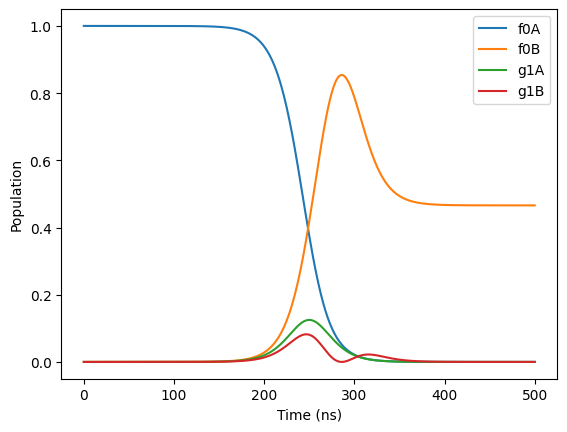

0.4659035954983818


In [ ]:


result = qt.mesolve(
    H, psi0, t, c_ops, e_ops, args=args, options=options, progress_bar=True
)

fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)
for i, l in enumerate(e_labels):
    ax.plot(t, np.abs(result.expect[i]), label=l)
ax.legend()
ax.set_xlabel("Time (ns)") ;ax.set_ylabel("Population")
plt.show()
print(result.expect[1][-1])